# ERS Investment Roadmap

| Section | Description |
|---|---|
| **1 -- Initialisation** | Installs packages, loads data, builds all parameter dashboards |
| **2 -- Dashboards** | Review and adjust inputs and probability distribution assumptions |
| **3 -- Optimisation** | Mathematical optimisation (Seeker by InsideOpt) + results |
| **4 -- Excel Export** | Downloads formatted Excel with tables and charts |

Please run the 4 sections individually if you want to use the dashboard feature to calculate the results. After running Section 1, a dashboard will appear that allows you to easily adjust the parameters and probability distributions manually without having to make changes to the code.

## Section 1 -- Initialisation & Dashboards

In [3]:
# ERS - Initialisation
import subprocess, sys, json, base64, math, io
subprocess.run([sys.executable,"-m","pip","install","ipywidgets","scipy","seekerdemo","-q"],check=True)
from google.colab import output as _co
_co.enable_custom_widget_manager()
import ipywidgets as w, pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as mgs
from IPython.display import display, HTML as IH
from collections import OrderedDict as OD
from scipy.stats import norm as _norm
_D=json.loads(base64.b64decode("eyJwYXJhbXMiOiB7Im1vZGVsX3N0YXJ0IjogMjAyNiwgIm1vZGVsX2VuZCI6IDIwNTAsICJzdG9wX3llYXIiOiAyMDQwLCAic3lzX2VmZiI6IDAuOSwgInRydWNrX2t3aCI6IDEuNSwgIm1haW50X3BjdCI6IDAuMDIsICJhc3NldF95ZWFycyI6IDIwLCAiY2hhcmdlX2ZhY3RvciI6IHsiY2VudGVyIjogMS41LCAiZGlzdCI6ICJVbmlmb3JtIiwgInAxIjogbnVsbCwgInAyIjogbnVsbH0sICJzZWxsX3ByaWNlIjogeyJjZW50ZXIiOiAwLjMsICJkaXN0IjogIlVuaWZvcm0iLCAicDEiOiBudWxsLCAicDIiOiBudWxsfSwgImVsZWNfcHJpY2UiOiB7ImNlbnRlciI6IDAuMTUsICJkaXN0IjogIlVuaWZvcm0iLCAicDEiOiBudWxsLCAicDIiOiBudWxsfSwgImNhcGV4IjogeyJjZW50ZXIiOiAzNTAwMDAwLjAsICJkaXN0IjogIkdhbW1hIChyaWdodC1za2V3ZWQpIiwgInAxIjogbnVsbCwgInAyIjogbnVsbH0sICJ3YWNjIjogeyJjZW50ZXIiOiAwLjA2LCAiZGlzdCI6ICJVbmlmb3JtIiwgInAxIjogbnVsbCwgInAyIjogbnVsbH0sICJkaWZmX2Jhc2UiOiB7ImNlbnRlciI6IDAuMDUsICJkaXN0IjogIlVuaWZvcm0iLCAicDEiOiBudWxsLCAicDIiOiBudWxsfSwgImRpZmZfbWF4IjogeyJjZW50ZXIiOiAwLjYsICJkaXN0IjogIlVuaWZvcm0iLCAicDEiOiBudWxsLCAicDIiOiBudWxsfSwgImRpZmZfdHVybiI6IHsiY2VudGVyIjogMTIuMCwgImRpc3QiOiAiTm9ybWFsIiwgInAxIjogbnVsbCwgInAyIjogbnVsbH0sICJkaWZmX2dyb3d0aCI6IHsiY2VudGVyIjogMC41LCAiZGlzdCI6ICJVbmlmb3JtIiwgInAxIjogbnVsbCwgInAyIjogbnVsbH19LCAiY291bnRyaWVzIjogW3sibmFtZSI6ICJDdXN0b20gQ291bnRyeSAxIiwgImluY2x1ZGUiOiBmYWxzZSwgImNiX2NlbnRlciI6IDAuNSwgImNiX2Rpc3QiOiAiVW5pZm9ybSIsICJjYl9wMSI6IDAuMCwgImNiX3AyIjogMS4wfSwgeyJuYW1lIjogIkN1c3RvbSBDb3VudHJ5IDIiLCAiaW5jbHVkZSI6IGZhbHNlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiQ3VzdG9tIENvdW50cnkgMyIsICJpbmNsdWRlIjogZmFsc2UsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJCZWxnaXVtIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiQnVsZ2FyaWEiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJEZW5tYXJrIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiR2VybWFueSIsICJpbmNsdWRlIjogdHJ1ZSwgImNiX2NlbnRlciI6IDAuNSwgImNiX2Rpc3QiOiAiVW5pZm9ybSIsICJjYl9wMSI6IDAuMCwgImNiX3AyIjogMS4wfSwgeyJuYW1lIjogIkVzdG9uaWEiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJGaW5sYW5kIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiRnJhbmNlIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiR3JlZWNlIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiSXRhbHkiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJDcm9hdGlhIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiTGl0aHVhbmlhIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiTmV0aGVybGFuZHMiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJBdXN0cmlhIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiUG9sYW5kIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiUG9ydHVnYWwiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJSb21hbmlhIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiU3dlZGVuIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiU2xvdmFraWEiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJTbG92ZW5pYSIsICJpbmNsdWRlIjogdHJ1ZSwgImNiX2NlbnRlciI6IDAuNSwgImNiX2Rpc3QiOiAiVW5pZm9ybSIsICJjYl9wMSI6IDAuMCwgImNiX3AyIjogMS4wfSwgeyJuYW1lIjogIlNwYWluIiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiQ3plY2ggUmVwdWJsaWMiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJIdW5nYXJ5IiwgImluY2x1ZGUiOiB0cnVlLCAiY2JfY2VudGVyIjogMC41LCAiY2JfZGlzdCI6ICJVbmlmb3JtIiwgImNiX3AxIjogMC4wLCAiY2JfcDIiOiAxLjB9LCB7Im5hbWUiOiAiU3dpdHplcmxhbmQiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH0sIHsibmFtZSI6ICJOb3J3YXkiLCAiaW5jbHVkZSI6IHRydWUsICJjYl9jZW50ZXIiOiAwLjUsICJjYl9kaXN0IjogIlVuaWZvcm0iLCAiY2JfcDEiOiAwLjAsICJjYl9wMiI6IDEuMH1dLCAibXBfcm93cyI6IFtbIkJlbGdpdW0iLCAiQmVsZ2l1bSIsIDExMDU2NjA2MjIuNDM0OTldLCBbIkJlbGdpdW0iLCAiRnJhbmNlIiwgMTk0Nzk3ODk3Ny40MTI2XSwgWyJCZWxnaXVtIiwgIk5ldGhlcmxhbmRzIiwgMTgwMjExODQ3OC4wNDk1M10sIFsiQmVsZ2l1bSIsICJHZXJtYW55IiwgNzYwMDEyNzUzLjY3NzQ3Nl0sIFsiQnVsZ2FyaWEiLCAiQnVsZ2FyaWEiLCA0NDQxODMyNTQuNDU2MjVdLCBbIkJ1bGdhcmlhIiwgIkdyZWVjZSIsIDI5NTAzMjMyMS4zMjUwMDNdLCBbIkJ1bGdhcmlhIiwgIlJvbWFuaWEiLCAxNjUwNzgzOTYuNDY5OTg4XSwgWyJEZW5tYXJrIiwgIkRlbm1hcmsiLCAxODg1NjYwOTA3LjUxNzQ5XSwgWyJEZW5tYXJrIiwgIkdlcm1hbnkiLCA3ODgwNjc3NjEuNDA2MzRdLCBbIkRlbm1hcmsiLCAiU3dlZGVuIiwgMzIxNjIzNDM5LjE2MjUzMl0sIFsiRGVubWFyayIsICJOb3J3YXkiLCAyNzcxNjI4MC4yODEyNTA0XSwgWyJHZXJtYW55IiwgIkdlcm1hbnkiLCAyMjYzMTk3ODc0My45MjZdLCBbIkdlcm1hbnkiLCAiTmV0aGVybGFuZHMiLCA2MjE2MjA2ODA2LjUyMjY3XSwgWyJHZXJtYW55IiwgIkF1c3RyaWEiLCA2NDgxNDUxMzAxLjkxMjYxXSwgWyJHZXJtYW55IiwgIlBvbGFuZCIsIDc1NDU5NTk3MTQuMjYzNDldLCBbIkdlcm1hbnkiLCAiQ3plY2ggUmVwdWJsaWMiLCAzMTcyOTY4MTU1LjEzMTk4XSwgWyJHZXJtYW55IiwgIkJlbGdpdW0iLCAyMTQzNTkyMjI3Ljc2ODI5XSwgWyJFc3RvbmlhIiwgIkVzdG9uaWEiLCA0MjYwNzU5NC4wNTEyNV0sIFsiRXN0b25pYSIsICJTd2VkZW4iLCA1NjYzNzYxMi43Nzg3NDk3XSwgWyJGaW5sYW5kIiwgIkZpbmxhbmQiLCA1NDU3MjczMDYuMTAxMjQ5XSwgWyJGaW5sYW5kIiwgIlN3ZWRlbiIsIDI1Mjc4OTUwOC40MjYyNDZdLCBbIkZpbmxhbmQiLCAiTm9yd2F5IiwgMzY0MjU5Mi40NDI1MDAwMV0sIFsiRnJhbmNlIiwgIkZyYW5jZSIsIDE2MDQzNzY0MTYzLjAyNDldLCBbIkZyYW5jZSIsICJTcGFpbiIsIDc2MDIyMDU2NTUuMDczMjVdLCBbIkZyYW5jZSIsICJCZWxnaXVtIiwgMzY5MjI4MjQ1Ni4yNzFdLCBbIkZyYW5jZSIsICJHZXJtYW55IiwgMjA2NTIwMTExNC4yMTcxNl0sIFsiRnJhbmNlIiwgIlN3aXR6ZXJsYW5kIiwgMTUwMzIwMTY0MC42MTM3OV0sIFsiRnJhbmNlIiwgIkl0YWx5IiwgMTQ2NTUyNTg2MS4yNjEyOF0sIFsiR3JlZWNlIiwgIkdyZWVjZSIsIDUxMjY0NTA5OC43Mjg3NV0sIFsiR3JlZWNlIiwgIkJ1bGdhcmlhIiwgNDA4ODczNDE1Ljg0MjQ5NV0sIFsiR3JlZWNlIiwgIkl0YWx5IiwgMTE4OTA1NjU3LjI5NzQ5OV0sIFsiSXRhbHkiLCAiSXRhbHkiLCAxMzk5NTgwNTU1Ny4yNTc1XSwgWyJJdGFseSIsICJBdXN0cmlhIiwgMTk2NjY1Nzc0NC43NTgwN10sIFsiSXRhbHkiLCAiU3dpdHplcmxhbmQiLCAxNzQxNDI0OTk2Ljk0MTcyXSwgWyJJdGFseSIsICJGcmFuY2UiLCAxNDY2NDk1NzM4LjM0NTA1XSwgWyJJdGFseSIsICJTbG92ZW5pYSIsIDE0NzY0ODQxNjMuNzY1NjFdLCBbIkl0YWx5IiwgIkdyZWVjZSIsIDE4NjU5Njk4MS4xNTQzNzRdLCBbIkNyb2F0aWEiLCAiQ3JvYXRpYSIsIDQ0MDI5ODE5MC4xNjQ5OTldLCBbIkNyb2F0aWEiLCAiU2xvdmVuaWEiLCA2MTc3OTExMDkuNzYxODg0XSwgWyJDcm9hdGlhIiwgIkh1bmdhcnkiLCA3ODg1NzAxMC4zNDg3NTAzXSwgWyJDcm9hdGlhIiwgIkl0YWx5IiwgMjIyMTEyMDIuMjM5Mzc1NV0sIFsiTGl0aHVhbmlhIiwgIkxpdGh1YW5pYSIsIDE5ODM1ODUzMy4yMjM3NDldLCBbIkxpdGh1YW5pYSIsICJQb2xhbmQiLCAyNDcxNzg2NTguMDU2ODc0XSwgWyJOZXRoZXJsYW5kcyIsICJOZXRoZXJsYW5kcyIsIDI2MjAxNDgzODUuMTcxMjVdLCBbIk5ldGhlcmxhbmRzIiwgIkdlcm1hbnkiLCAxODc0MDg5NDQ2LjQ4MzQ5XSwgWyJOZXRoZXJsYW5kcyIsICJCZWxnaXVtIiwgMTMzNTcwMDYwOS4zOTk4MV0sIFsiQXVzdHJpYSIsICJBdXN0cmlhIiwgMTI0ODQ5Mjg1My4yNjc0OV0sIFsiQXVzdHJpYSIsICJHZXJtYW55IiwgMjA1OTE2MjU3MS4yMzg5Ml0sIFsiQXVzdHJpYSIsICJIdW5nYXJ5IiwgODkxOTc3Nzg3LjE3OTk2M10sIFsiQXVzdHJpYSIsICJDemVjaCBSZXB1YmxpYyIsIDgwMDYzODU3Ni4wNTU1MjhdLCBbIkF1c3RyaWEiLCAiSXRhbHkiLCA3NzI0MzI4NjYuNDA2ODJdLCBbIkF1c3RyaWEiLCAiU2xvdmVuaWEiLCA1NTE0NDgyMzguNTU1NTM5XSwgWyJQb2xhbmQiLCAiUG9sYW5kIiwgMTQ3OTM3NDUzNzguMDUyNV0sIFsiUG9sYW5kIiwgIkdlcm1hbnkiLCA1NjU3MjcxMjc1LjEyODQ4XSwgWyJQb2xhbmQiLCAiQ3plY2ggUmVwdWJsaWMiLCAxOTQyNzc3Njk4LjEyNDI3XSwgWyJQb2xhbmQiLCAiTGl0aHVhbmlhIiwgNjc4MjE1Nzk3LjY1NDM2OV0sIFsiUG9sYW5kIiwgIlNsb3Zha2lhIiwgNTE0MDk5NzQ0LjM4NzQ5Nl0sIFsiUG9ydHVnYWwiLCAiUG9ydHVnYWwiLCAzNDI2MjM4MjQuNjUxMjQ5XSwgWyJQb3J0dWdhbCIsICJTcGFpbiIsIDgxOTIxOTc3MC4wNzMxODddLCBbIlJvbWFuaWEiLCAiUm9tYW5pYSIsIDg3NzMwODk0My45MzM3NDldLCBbIlJvbWFuaWEiLCAiSHVuZ2FyeSIsIDg3MDUzMjEwOC4wMzkzMzddLCBbIlJvbWFuaWEiLCAiQnVsZ2FyaWEiLCAzMTE2ODQ0NzMuNjgzNzQ0XSwgWyJTd2VkZW4iLCAiU3dlZGVuIiwgNjY4NTY1MzIxNS4yMzVdLCBbIlN3ZWRlbiIsICJEZW5tYXJrIiwgOTI4NDgzMTc0LjIxODczXSwgWyJTd2VkZW4iLCAiTm9yd2F5IiwgNDkzMDkwODc0LjY2NTYyNF0sIFsiU3dlZGVuIiwgIkZpbmxhbmQiLCAzMDgxNjQ0NzIuODQ2MjUzXSwgWyJTd2VkZW4iLCAiRXN0b25pYSIsIDcxODQ3Mjg5LjUyNzVdLCBbIlN3ZWRlbiIsICJHZXJtYW55IiwgNjg2MjEuMDAyNV0sIFsiU2xvdmFraWEiLCAiU2xvdmFraWEiLCAxMDc5OTI2OTQwLjgyMzc1XSwgWyJTbG92YWtpYSIsICJDemVjaCBSZXB1YmxpYyIsIDUzNTQ0Mzk0NS43MTU2NF0sIFsiU2xvdmFraWEiLCAiSHVuZ2FyeSIsIDU3OTk4ODYxNy4yNTY4ODZdLCBbIlNsb3Zha2lhIiwgIlBvbGFuZCIsIDIyODA5NjQ0OS4yNTY4ODJdLCBbIlNsb3ZlbmlhIiwgIlNsb3ZlbmlhIiwgMTA5ODkzOTE2LjQ2Mzc0OV0sIFsiU2xvdmVuaWEiLCAiSXRhbHkiLCA0NjM3MzE4NTQuNjIwNjIyXSwgWyJTbG92ZW5pYSIsICJBdXN0cmlhIiwgMzI3NjExMjAxLjU5NDQ1XSwgWyJTbG92ZW5pYSIsICJDcm9hdGlhIiwgMjg0MzcyODg0LjI5NzQ2MV0sIFsiU2xvdmVuaWEiLCAiSHVuZ2FyeSIsIDE3OTIxODI1My4wMzI1MDddLCBbIlNwYWluIiwgIlNwYWluIiwgNzg0OTc4MjM5NS45XSwgWyJTcGFpbiIsICJGcmFuY2UiLCA1NjE1Mzc2OTg0LjExNTg3XSwgWyJTcGFpbiIsICJQb3J0dWdhbCIsIDE0NjEyMzM5MDcuMjIyMTZdLCBbIkN6ZWNoIFJlcHVibGljIiwgIkN6ZWNoIFJlcHVibGljIiwgMTk2MDI3OTI0Ni44MTg3NV0sIFsiQ3plY2ggUmVwdWJsaWMiLCAiR2VybWFueSIsIDE4ODk1ODQwNDQuNTA0NDVdLCBbIkN6ZWNoIFJlcHVibGljIiwgIlBvbGFuZCIsIDEwOTg5MzgwOTUuODM4NzJdLCBbIkN6ZWNoIFJlcHVibGljIiwgIlNsb3Zha2lhIiwgODU0MzUxMDU3LjI3NTExMV0sIFsiQ3plY2ggUmVwdWJsaWMiLCAiQXVzdHJpYSIsIDY5Mzg1ODQyNi45NDE3ODVdLCBbIkh1bmdhcnkiLCAiSHVuZ2FyeSIsIDU3MTg0MDg4OS40MV0sIFsiSHVuZ2FyeSIsICJBdXN0cmlhIiwgNzc3ODk3NDcwLjE5MjYyOV0sIFsiSHVuZ2FyeSIsICJTbG92YWtpYSIsIDc0Njk5MjUwMC44ODE4NDVdLCBbIkh1bmdhcnkiLCAiUm9tYW5pYSIsIDc0ODUzNDk3MS40ODQ5MjZdLCBbIkh1bmdhcnkiLCAiU2xvdmVuaWEiLCAyOTY4OTMyNDEuOTExMjU0XSwgWyJIdW5nYXJ5IiwgIkNyb2F0aWEiLCAxMTc3ODkxNTcuODU2ODczXSwgWyJTd2l0emVybGFuZCIsICJTd2l0emVybGFuZCIsIDc2NzYwNTU1NS4wODg3NV0sIFsiU3dpdHplcmxhbmQiLCAiSXRhbHkiLCAxMDk2NTM4MjA0LjYzNzIyXSwgWyJTd2l0emVybGFuZCIsICJGcmFuY2UiLCA3NDc3NzkyOTguMTc1MzM0XSwgWyJTd2l0emVybGFuZCIsICJBdXN0cmlhIiwgNTA4OTg1MTMyLjg2ODc1MV0sIFsiU3dpdHplcmxhbmQiLCAiR2VybWFueSIsIDQ3NDY4NTEwNC4yODU2NjVdLCBbIk5vcndheSIsICJOb3J3YXkiLCA0NDA0Mzg1NTAuMjM2MjVdLCBbIk5vcndheSIsICJTd2VkZW4iLCAzMDAzOTY1MzQuNDkwNjI0XSwgWyJOb3J3YXkiLCAiRGVubWFyayIsIDQxNDc5MTc1LjY1MTI1MDJdLCBbIk5vcndheSIsICJGaW5sYW5kIiwgNTAwODY5LjM5Mzc0OTk5OV1dLCAic2tld25lc3MiOiB7IkF1c3RyaWEiOiAwLjgxNDQzNjY3MjEzNjA1OSwgIkJlbGdpdW0iOiAwLjg5MDkzNjEzNjU2Mjc3MSwgIkJ1bGdhcmlhIjogMC45NjE4MzE3NDcyMzM2NCwgIlN3aXR6ZXJsYW5kIjogMS4xMDYzNjY2OTM2ODg2OSwgIkN6ZWNoIFJlcHVibGljIjogMC45MDI4NTc5MTU2ODc5MTYsICJHZXJtYW55IjogMC44Mjk1MDUyMjE2OTgxODUsICJEZW5tYXJrIjogMS4yMTA3MTgzOTk5NTgyMSwgIkVzdG9uaWEiOiAwLjkwNjAzODIwMTAwMDQ2MiwgIlNwYWluIjogMS4xOTk5OTg0MTg1NzA2OCwgIkZpbmxhbmQiOiAxLjYwOTY2MzI5MjEyMTExLCAiRnJhbmNlIjogMS4xMDMzNDc5MjIzNjczNiwgIkdyZWVjZSI6IDEuMjA4NjE0OTA1MTQ0NjYsICJDcm9hdGlhIjogMS44ODU4MTUwNDM1OTEyNywgIkh1bmdhcnkiOiAwLjgzOTI0MjA1NDk4MDM5MSwgIkl0YWx5IjogMS40NzMxNDg4MDg3MDkxOSwgIkxpdGh1YW5pYSI6IDAuNzA2OTc4ODgyNDM2ODc1LCAiTmV0aGVybGFuZHMiOiAwLjkzNTI5MzIyODkwMDMyNywgIk5vcndheSI6IDEuMjI0MDYwNTUzNzUzOTQsICJQb2xhbmQiOiAwLjk0MTk1NDk1MDI2ODcsICJQb3J0dWdhbCI6IDEuMDIyMTE5Nzg5Njk4MjQsICJSb21hbmlhIjogMS4wODMxNTQyNzY0MDA4OSwgIlN3ZWRlbiI6IDEuMjg4MzUxNTEzMDY5MzQsICJTbG92ZW5pYSI6IDAuOTY5NTY1MjM1NTc0MTI5LCAiU2xvdmFraWEiOiAwLjkxODc1MzUyNTg3NzQ4N30sICJoaWdod2F5IjogeyJCZWxnaXVtIjogMTc2My4wLCAiQnVsZ2FyaWEiOiA4MjUuMCwgIkRlbm1hcmsiOiAxMzU1LjAsICJHZXJtYW55IjogMTMxNzIuMCwgIkVzdG9uaWEiOiAyMjUuMCwgIkZpbmxhbmQiOiA5NDguMCwgIkZyYW5jZSI6IDExNzUxLjI3MiwgIkdyZWVjZSI6IDIyMDUuMCwgIklyZWxhbmQiOiA5OTUuMCwgIkl0YWx5IjogNzU1Ni4wLCAiQ3JvYXRpYSI6IDEzNDEuMCwgIkxhdHZpYSI6IDEuMCwgIkxpdGh1YW5pYSI6IDQwMC4wLCAiTHV4ZW1ib3VyZyI6IDE2My4wLCAiTWFsdGEiOiAxLjAsICJOZXRoZXJsYW5kcyI6IDI3OTMuMCwgIkF1c3RyaWEiOiAxNzQ5LjAsICJQb2xhbmQiOiAxODAyLjAsICJQb3J0dWdhbCI6IDMxMTUuMCwgIlJvbWFuaWEiOiA5NDkuMCwgIlN3ZWRlbiI6IDIxOTMuMCwgIlNsb3Zha2lhIjogODYxLjIsICJTbG92ZW5pYSI6IDYxNi4wMjMsICJTcGFpbiI6IDE1ODI1LjAsICJDemVjaCBSZXB1YmxpYyI6IDEzNjMuMCwgIkh1bmdhcnkiOiAxODY3LjYsICJDeXBydXMiOiAyNzEuMCwgIlN3aXR6ZXJsYW5kIjogMTU0NC4wLCAiTm9yd2F5IjogNTgwLjB9fQ==").decode())
P=_D["params"]; COUNTRIES=_D["countries"]; MP=_D["mp_rows"]; SK=_D["skewness"]; HW=_D["highway"]
ALL=[c["name"] for c in COUNTRIES]
DEFAULT_INCLUDE={'Germany', 'France', 'Belgium', 'Poland', 'Italy', 'Netherlands'}

DO=["Uniform","Normal","Gamma (right-skewed)"]
DL={"Uniform":("Lower Bound","Upper Bound"),"Normal":("Std. Dev.","Cutoff (opt.)"),"Gamma (right-skewed)":("Shape k>0","Scale k>0")}

def lw(p): return w.Layout(width=f"{p}px")
def lb(t,p=185): return w.Label(value=t,layout=lw(p))
def hdr(t): return w.HTML(f'<div style="font-size:13px;font-weight:600;color:#1F4E79;border-bottom:2px solid #2E75B6;padding-bottom:3px;margin:10px 0 5px">{t}</div>')
def note(t): return w.HTML(f'<div style="font-size:11px;color:#595959;background:#f5f7fa;padding:5px 9px;border-left:3px solid #2E75B6;margin:3px 0 6px">{t}</div>')
def kpi_box(t): return w.HTML(f'<div style="font-size:11px;color:#1F4E79;background:#e8f4fd;padding:5px 9px;border-radius:4px;margin:3px 0 4px">{t}</div>')
def txt(val,px=105): return w.Text(value=str(val),layout=lw(px))
def _fv(x):
    try: return float(x.value) if hasattr(x,"value") else float(x)
    except: return 0.0

def srow_txt(lbl,cv,dv,p1v,p2v,lp=185):
    c=txt(cv,105)
    d=w.Dropdown(options=DO,value=dv if dv in DO else "Uniform",layout=lw(160))
    p1l=w.Label(value=DL[d.value][0],layout=lw(110))
    p1=txt(p1v or "",80)
    p2l=w.Label(value=DL[d.value][1],layout=lw(120))
    p2=txt(p2v or "",80)
    def oc(ch): p1l.value,p2l.value=DL[ch["new"]]
    d.observe(oc,names="value")
    row=w.HBox([lb(lbl,lp),c,w.Label("dist:",layout=lw(32)),d,p1l,p1,p2l,p2],layout=w.Layout(align_items="center",margin="2px 0"))
    return row,c,d,p1,p2

def panel_wrap(step,title,content):
    return w.VBox([
        w.HTML(f'<div style="background:#1F4E79;color:#fff;padding:8px 14px;border-radius:5px;margin-bottom:8px"><b>Step {step} -- {title}</b></div>'),
        content,
        w.HTML('<hr style="border:none;border-top:1px solid #ddd;margin:10px 0">')
    ])

# P1 General
wms=w.IntText(value=P["model_start"],layout=lw(70))
wme=w.IntText(value=P["model_end"],  layout=lw(70))
wsy=w.IntText(value=P["stop_year"],  layout=lw(70))
wse=txt(P["sys_eff"],70)
wtk=txt(P["truck_kwh"],70)

# Optimisation objective
w_obj=w.Dropdown(
    options=[
        ("Maximise E[profit] only","mean"),
        ("Maximise E[profit] + Q05 (risk-adjusted)","mean_q05"),
        ("Custom weight: E[profit] and Q05","weighted"),
    ],
    value="mean_q05",layout=lw(320)
)
w_weight=w.FloatSlider(value=0.5,min=0.0,max=1.0,step=0.05,
    description="E[profit] weight:",layout=w.Layout(width="350px"),
    style={"description_width":"120px"})
w_weight_note=w.Output()
def _wn(*_):
    w_weight_note.clear_output(wait=True)
    obj=w_obj.value
    w_weight.layout.display = "" if obj=="weighted" else "none"
    with w_weight_note:
        if obj=="mean":
            display(w.HTML('<div style="font-size:11px;color:#595959">Objective = 100% E[profit]  (Q05 not used)</div>'))
        elif obj=="mean_q05":
            display(w.HTML('<div style="font-size:11px;color:#595959">Objective = 50% E[profit] + 50% Q05</div>'))
        else:
            wv=w_weight.value
            display(w.HTML(f'<div style="font-size:11px;color:#595959">Objective = {wv:.0%} x E[profit] + {1-wv:.0%} x Q05</div>'))
w_obj.observe(_wn,"value"); w_weight.observe(_wn,"value"); _wn()

p1=panel_wrap(1,"General Parameters",w.VBox([
    hdr("Model Horizon"),
    w.HBox([lb("Start year"),wms,lb("  End year",80),wme,lb("  Last expansion year",160),wsy]),
    hdr("Technical"),
    w.HBox([lb("System efficiency"),wse,lb("  Truck consumption (kWh/km)",210),wtk]),
    hdr("Optimisation Objective"),
    w.HBox([lb("Objective function"),w_obj]),
    w_weight,w_weight_note,
]))

# P2 Revenue
rch,wcc,wcd,wcp1,wcp2=srow_txt("Charging factor",        P["charge_factor"]["center"],P["charge_factor"]["dist"],P["charge_factor"]["p1"],P["charge_factor"]["p2"])
rsp,wsc,wsd,wsp1,wsp2=srow_txt("Selling price (EUR/kWh)", P["sell_price"]["center"],   P["sell_price"]["dist"],   P["sell_price"]["p1"],   P["sell_price"]["p2"])
rev_kpi=w.Output()
def _rev(*_):
    rev_kpi.clear_output(wait=True)
    try:
        r=_fv(wsc)/_fv(wse)*_fv(wtk)*_fv(wcc)
        with rev_kpi: display(kpi_box(f"Revenue per truck-km (central): <b>{r:.4f} EUR/truck-km</b>"))
    except: pass
wsc.observe(_rev,"value"); wcc.observe(_rev,"value"); _rev()
p2=panel_wrap(2,"Revenue",w.VBox([
    note("Revenue per truck-km = selling_price / sys_eff x truck_kwh x charging_factor"),
    rch,rsp,rev_kpi
]))

# P3 Costs
rel,wec,wed,wep1,wep2=srow_txt("Electricity price (EUR/kWh)",P["elec_price"]["center"],P["elec_price"]["dist"],P["elec_price"]["p1"],P["elec_price"]["p2"])
wmp_=txt(P["maint_pct"],70)
cost_kpi=w.Output()
def _cost(*_):
    cost_kpi.clear_output(wait=True)
    try:
        c=_fv(wec)/_fv(wse)*_fv(wtk)*_fv(wcc)
        with cost_kpi: display(kpi_box(f"Electricity cost per truck-km (central): <b>{c:.4f} EUR/truck-km</b>"))
    except: pass
wec.observe(_cost,"value"); _cost()
p3=panel_wrap(3,"Costs",w.VBox([
    hdr("Electricity"),
    note("Electricity cost per truck-km = elec_price / sys_eff x truck_kwh x charging_factor"),
    rel,cost_kpi,
    hdr("Maintenance"),
    w.HBox([lb("Maintenance (% of capex/yr)"),wmp_]),
]))

# P4 Capex & Financing
rcx,wxc,wxd,wxp1,wxp2=srow_txt("Expansion cost (EUR/km)",P["capex"]["center"],P["capex"]["dist"],P["capex"]["p1"],P["capex"]["p2"])
rwc,wwc,wwd,wwp1,wwp2=srow_txt("WACC",                   P["wacc"]["center"], P["wacc"]["dist"], P["wacc"]["p1"], P["wacc"]["p2"])
way=w.IntText(value=P["asset_years"],layout=lw(70))
wann=w.Output()
def _ann(*_):
    wann.clear_output(wait=True)
    try:
        a=_fv(wxc)*_fv(wwc)/(1-(1+_fv(wwc))**(-way.value))
        with wann: display(kpi_box(f"Annuity per km (central): <b>{a:,.0f} EUR/km/yr</b> (financing: {way.value} years)"))
    except: pass
wxc.observe(_ann,"value"); wwc.observe(_ann,"value"); way.observe(_ann,"value"); _ann()
p4=panel_wrap(4,"Capex & Financing",w.VBox([
    hdr("Capital Expenditure"),rcx,
    hdr("Financing"),
    w.HBox([lb("Financing years"),way]),
    rwc,wann
]))

# P5 Diffusion
rba,wdbc,wdbd,wdbp1,wdbp2=srow_txt("Base (min penetration)", P["diff_base"]["center"],  P["diff_base"]["dist"],  P["diff_base"]["p1"],  P["diff_base"]["p2"])
rma,wdmc,wdmd,wdmp1,wdmp2=srow_txt("Max (max penetration)",  P["diff_max"]["center"],   P["diff_max"]["dist"],   P["diff_max"]["p1"],   P["diff_max"]["p2"])
wdtc_int=w.IntText(value=int(P["diff_turn"]["center"]),layout=lw(105))
wdtd=w.Dropdown(options=DO,value=P["diff_turn"]["dist"] if P["diff_turn"]["dist"] in DO else "Normal",layout=lw(160))
wdtp1=txt(P["diff_turn"]["p1"] or "",80); wdtp2=txt(P["diff_turn"]["p2"] or "",80)
wdtl1=w.Label(value=DL[wdtd.value][0],layout=lw(110)); wdtl2=w.Label(value=DL[wdtd.value][1],layout=lw(120))
def _dtd_obs(ch): wdtl1.value,wdtl2.value=DL[ch["new"]]
wdtd.observe(_dtd_obs,names="value")
rtu2=w.HBox([lb("Turn (inflection year)",185),wdtc_int,w.Label("dist:",layout=lw(32)),wdtd,wdtl1,wdtp1,wdtl2,wdtp2],layout=w.Layout(align_items="center",margin="2px 0"))
rgr,wdgc,wdgd,wdgp1,wdgp2=srow_txt("Growth rate",P["diff_growth"]["center"],P["diff_growth"]["dist"],P["diff_growth"]["p1"],P["diff_growth"]["p2"])
diff_chart=w.Output()
def _draw_diff(*_):
    diff_chart.clear_output(wait=True)
    try:
        years2=list(range(wms.value,wme.value+1))
        b2,m2,turn2,g2=_fv(wdbc),_fv(wdmc),wdtc_int.value,_fv(wdgc)
        dv=[b2+(m2-b2)/(1+math.exp(-g2*(t-turn2))) for t in range(len(years2))]
        with diff_chart:
            fig2,ax2=plt.subplots(figsize=(7,2.5))
            ax2.plot(years2,[v*100 for v in dv],color="#2E75B6",lw=2)
            ax2.fill_between(years2,[v*100 for v in dv],alpha=0.12,color="#2E75B6")
            ax2.set_ylabel("Market penetration (%)"); ax2.set_ylim(0,100)
            ax2.set_title("Diffusion curve preview",fontsize=10)
            ax2.grid(axis="y",alpha=0.3); plt.tight_layout(); plt.show()
    except: pass
for ww2 in [wdbc,wdmc,wdtc_int,wdgc,wms,wme]: ww2.observe(_draw_diff,"value")
_draw_diff()
p5=panel_wrap(5,"Market Diffusion",w.VBox([
    note("diff(t) = base + (max-base) / (1 + exp(-growth x (t-turn)))"),
    rba,rma,rtu2,rgr,diff_chart
]))

# P6 Market Potential -- simple flat list, one row per country
# Domestic = truck-km performed AND charged within the country
# Cross-border total = all truck-km performed in country by foreign trucks

_mp_dom_default={'Belgium': 1105660622.43499, 'Bulgaria': 444183254.45625, 'Denmark': 1885660907.51749, 'Germany': 22631978743.926, 'Estonia': 42607594.05125, 'Finland': 545727306.101249, 'France': 16043764163.0249, 'Greece': 512645098.72875, 'Italy': 13995805557.2575, 'Croatia': 440298190.164999, 'Lithuania': 198358533.223749, 'Netherlands': 2620148385.17125, 'Austria': 1248492853.26749, 'Poland': 14793745378.0525, 'Portugal': 342623824.651249, 'Romania': 877308943.933749, 'Sweden': 6685653215.235, 'Slovakia': 1079926940.82375, 'Slovenia': 109893916.463749, 'Spain': 7849782395.9, 'Czech Republic': 1960279246.81875, 'Hungary': 571840889.41, 'Switzerland': 767605555.08875, 'Norway': 440438550.23625}
_mp_cb_default={'Belgium': 4510110209.139606, 'Bulgaria': 460110717.794991, 'Denmark': 1137407480.8501225, 'Germany': 25560178205.59904, 'Estonia': 56637612.7787497, 'Finland': 256432100.86874598, 'France': 16328416727.43648, 'Greece': 527779073.139994, 'Italy': 6837659624.964824, 'Croatia': 718859322.3500098, 'Lithuania': 247178658.056874, 'Netherlands': 3209790055.8833, 'Austria': 5075660039.43677, 'Poland': 8792364515.294617, 'Portugal': 819219770.073187, 'Romania': 1182216581.723081, 'Sweden': 1801654432.260607, 'Slovakia': 1343529012.229408, 'Slovenia': 1254934193.54504, 'Spain': 7076610891.338031, 'Czech Republic': 4536731624.560066, 'Hungary': 2688107342.3275266, 'Switzerland': 2827987739.96697, 'Norway': 342376579.5356242}

# Two widgets per country: domestic FloatText, cross-border FloatText
# Plus for custom countries: name Text widget + highway Text widget
mp_dom_w={}   # cn -> FloatText (domestic truck-km)
mp_cb_w={}    # cn -> FloatText (cross-border truck-km)
mp_name_w={}  # cn -> Text (custom countries only, for renaming)
hw_w={}       # cn -> Text (highway network km, editable for all)

# Header row
mp_hdr=w.HBox([
    w.HTML('<b style="font-size:11px;width:175px;display:inline-block">Country</b>'),
    w.HTML('<b style="font-size:11px;width:155px;display:inline-block">Domestic (truck-km/yr)</b>'),
    w.HTML('<b style="font-size:11px;width:155px;display:inline-block">Cross-border (truck-km/yr)</b>'),
    w.HTML('<b style="font-size:11px;width:100px;display:inline-block">Highway (km)</b>'),
])

mp_rows_widgets=[]
for c in COUNTRIES:
    cn=c["name"]
    is_custom=cn.startswith("Custom")
    dom_val=_mp_dom_default.get(cn,0.0)
    cb_val=_mp_cb_default.get(cn,0.0)
    hw_val=HW.get(cn,0.0)
    dom_w2=w.Text(value=str(int(round(float(dom_val)))),layout=lw(148))
    cb_w2 =w.Text(value=str(int(round(float(cb_val)))), layout=lw(148))
    hw_w2 =txt(hw_val,93)
    mp_dom_w[cn]=dom_w2; mp_cb_w[cn]=cb_w2; hw_w[cn]=hw_w2
    if is_custom:
        name_w2=txt(cn,168)
        mp_name_w[cn]=name_w2
        mp_rows_widgets.append(w.HBox([name_w2,dom_w2,cb_w2,hw_w2],layout=w.Layout(align_items="center",margin="2px 0")))
    else:
        mp_rows_widgets.append(w.HBox([lb(cn,175),dom_w2,cb_w2,hw_w2],layout=w.Layout(align_items="center",margin="2px 0")))

p6=panel_wrap(6,"Market Potential",w.VBox([
    note("Domestic = truck-km performed and charged within the country. Cross-border = truck-km performed here by trucks originating abroad. Highway = total motorway network (km). Custom country names entered here carry through to all panels."),
    mp_hdr,
    *mp_rows_widgets
]))

# P7 Skewness
skw={}; skr_rows2=[]
for cn2 in ALL:
    v=SK.get(cn2); sv=txt(f"{v:.2f}" if v else "0.90",80); skw[cn2]=sv
    skr_rows2.append((cn2,sv,v))
sk_dd=w.Dropdown(options=[(cn2,cn2) for cn2 in ALL if HW.get(cn2,0)>0],
                 value="Germany" if HW.get("Germany",0)>0 else ALL[0],layout=lw(200))
sk_chart=w.Output()
def _draw_sk(*_):
    sk_chart.clear_output(wait=True)
    try:
        cn2=sk_dd.value
        # Use editable highway value from P6
        max_km=min(_fv(hw_w.get(cn2,txt("1000"))),6000)
        if max_km<=0: return
        sig=float(skw[cn2].value)
        kms=list(range(100,int(max_km)+1,100))
        pens=[]
        for km in kms:
            anteil=min(max(km/max_km,1e-7),1-1e-7)
            pen=float(np.clip(1-_norm.cdf(_norm.ppf(1-anteil)-sig**2),0,1))*100
            pens.append(pen)
        with sk_chart:
            fig3,ax3=plt.subplots(figsize=(5,2.5))
            ax3.plot(kms,pens,color="#2E75B6",lw=2)
            ax3.fill_between(kms,pens,alpha=0.12,color="#2E75B6")
            ax3.set_xlabel("Infrastructure built (km)"); ax3.set_ylabel("Market reach (%)")
            ax3.set_ylim(0,100); ax3.set_title(f"Penetration curve -- {cn2}",fontsize=10)
            ax3.grid(axis="y",alpha=0.3); plt.tight_layout(); plt.show()
    except: pass
sk_dd.observe(_draw_sk,"value")
for _,sv2,_ in skr_rows2: sv2.observe(_draw_sk,"value")
for cn2 in ALL:
    if cn2 in hw_w: hw_w[cn2].observe(_draw_sk,"value")
_draw_sk()
sk_tbl=[w.HBox([
    w.HTML('<b style="font-size:11px;width:188px;display:inline-block">Country</b>'),
    w.HTML('<b style="font-size:11px;width:100px;display:inline-block">sigma_gini</b>'),
    w.HTML('<b style="font-size:11px">Note</b>')])]
for cn2,sv2,v in skr_rows2:
    _lbl_sk = mp_name_w[cn2] if cn2 in mp_name_w else lb(cn2,188)
    sk_tbl.append(w.HBox([_lbl_sk,sv2,
        w.Label("from network data" if v else "default 0.90")],
        layout=w.Layout(align_items="center",margin="1px 0")))
p7=panel_wrap(7,"Skewness of Distribution (sigma_gini)",w.HBox([
    w.VBox(sk_tbl,layout=w.Layout(flex="0 0 auto")),
    w.VBox([w.HBox([w.Label("Preview for:",layout=lw(80)),sk_dd]),sk_chart],
           layout=w.Layout(margin="0 0 0 24px"))
]))

# P8 Countries
cww={}
cr_=[w.HBox([lb("Country",175),
    w.HTML('<b style="font-size:11px;width:55px;display:inline-block">Include</b>'),
    w.HTML('<b style="font-size:11px;width:95px;display:inline-block">CB prob</b>'),
    w.HTML('<b style="font-size:11px;width:150px;display:inline-block">Distribution</b>'),
    w.HTML('<b style="font-size:11px;width:104px;display:inline-block">Param 1</b>'),
    w.HTML('<b style="font-size:11px;width:73px;display:inline-block">val</b>'),
    w.HTML('<b style="font-size:11px;width:113px;display:inline-block">Param 2</b>'),
    w.HTML('<b style="font-size:11px">val</b>')])]
for c in COUNTRIES:
    cn2=c["name"]
    is_cust=cn2.startswith("Custom")
    # Use name from P6 if custom
    name_lbl=mp_name_w[cn2] if is_cust and cn2 in mp_name_w else lb(cn2,175)
    cb_=w.Checkbox(value=cn2 in DEFAULT_INCLUDE,indent=False,layout=lw(52))
    ct_=txt(c["cb_center"],90)
    dd_=w.Dropdown(options=DO,value=c["cb_dist"] if c["cb_dist"] in DO else "Uniform",layout=lw(145))
    p1l_=w.Label(value=DL[dd_.value][0],layout=lw(101)); p1v_=txt(c["cb_p1"],68)
    p2l_=w.Label(value=DL[dd_.value][1],layout=lw(110)); p2v_=txt(c["cb_p2"],68)
    def _mo(a=p1l_,b2=p2l_):
        def f(ch): a.value,b2.value=DL[ch["new"]]
        return f
    dd_.observe(_mo(),names="value")
    cr_.append(w.HBox([name_lbl,cb_,ct_,dd_,p1l_,p1v_,p2l_,p2v_],layout=w.Layout(align_items="center",margin="1px 0")))
    cww[cn2]={"cb":cb_,"ctr":ct_,"dist":dd_,"p1":p1v_,"p2":p2v_}
p8=panel_wrap(8,"Countries & Cross-Border Probability",w.VBox([
    note("Cross-border probability: 0=domestic only, 1=full cross-border. Combines likelihood of neighbour ERS build-out, border proximity of traffic, and bilateral intensity."),
    *cr_
]))

display(w.HTML('''<div style="background:#1F4E79;color:#fff;padding:14px 20px;border-radius:7px;margin-bottom:14px">
  <div style="font-size:18px;font-weight:600">ERS Investment Roadmap</div>
  <div style="font-size:12px;opacity:.8;margin-top:3px">
    Section 2: Review dashboards below | Section 3: Run Optimise | Section 4: Run Excel Export
  </div>
</div>'''))
for panel in [p1,p2,p3,p4,p5,p6,p7,p8]:
    o=w.Output()
    with o: display(panel)
    display(o)

HTML(value='<div style="background:#1F4E79;color:#fff;padding:14px 20px;border-radius:7px;margin-bottom:14px">…

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

---
## Section 3 -- Mathematical Optimization (Uses Demo Version of Solver "Seeker" by InsideOpt)

After running this section, charts displaying the results for all countries selected for optimization in the dashboard will appear.

Optimising Belgium...
At time 2.127691: Objective = 0.000000; Status = Feasible; Evaluations = 391
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 4.330799: Objective = 0.000000; Status = Feasible; Evaluations = 665
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 6.335635: Objective = 0.000000; Status = Feasible; Evaluations = 1092
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 8.489708: Objective = 0.000000; Status = Feasible; Evaluations = 1618
	E_profit_M = 0.000000; Q05_M = 0.000000; 
  E[profit]=0.0M EUR  opt_infra=0km
Optimising Germany...
At time 2.105309: Objective = 0.000000; Status = Feasible; Evaluations = 385
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 4.212623: Objective = 0.000000; Status = Feasible; Evaluations = 668
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 6.221699: Objective = 0.000000; Status = Feasible; Evaluations = 1020
	E_profit_M = 0.000000; Q05_M = 0.000000; 
At time 8.404729: Objective = 0.000000; Status = Feasible; Evaluations = 1440

/tmp/ipykernel_14476/1838431170.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


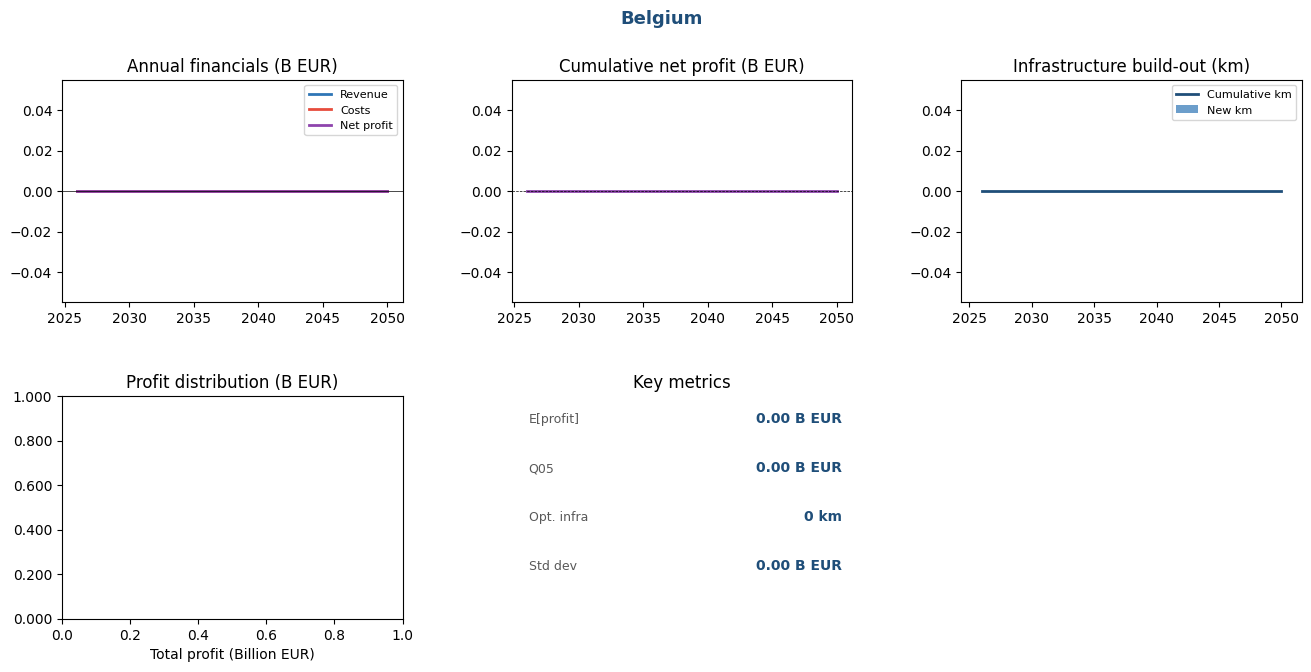

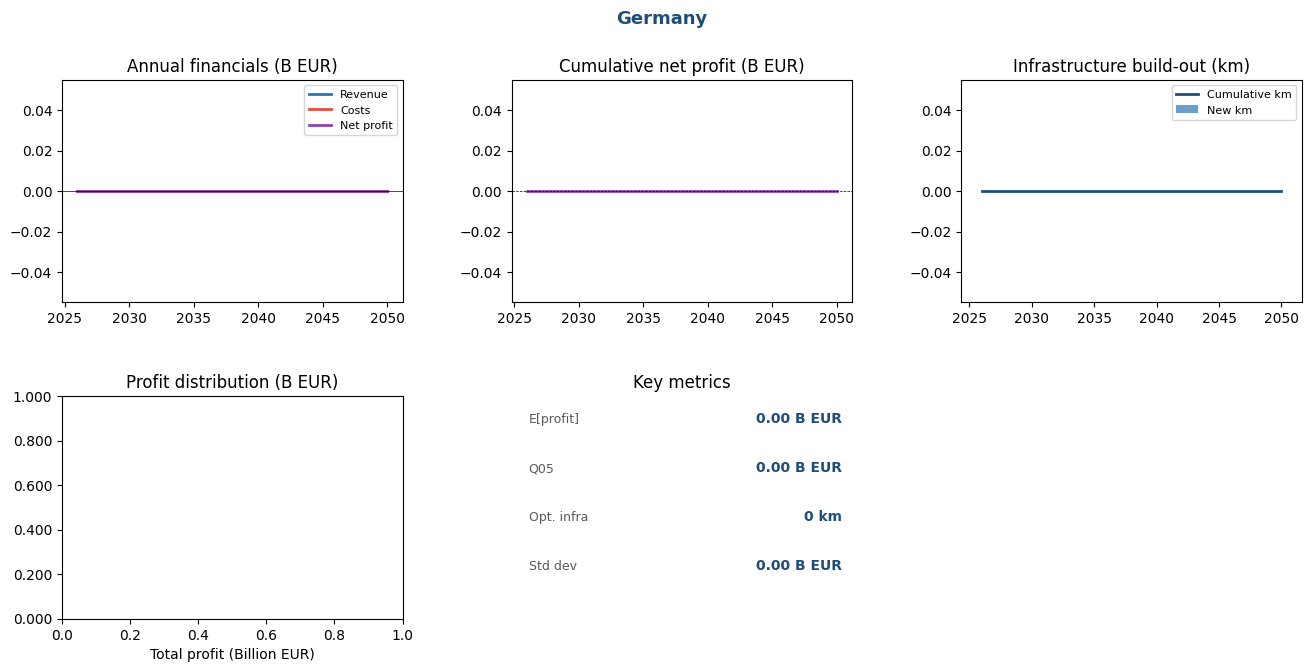

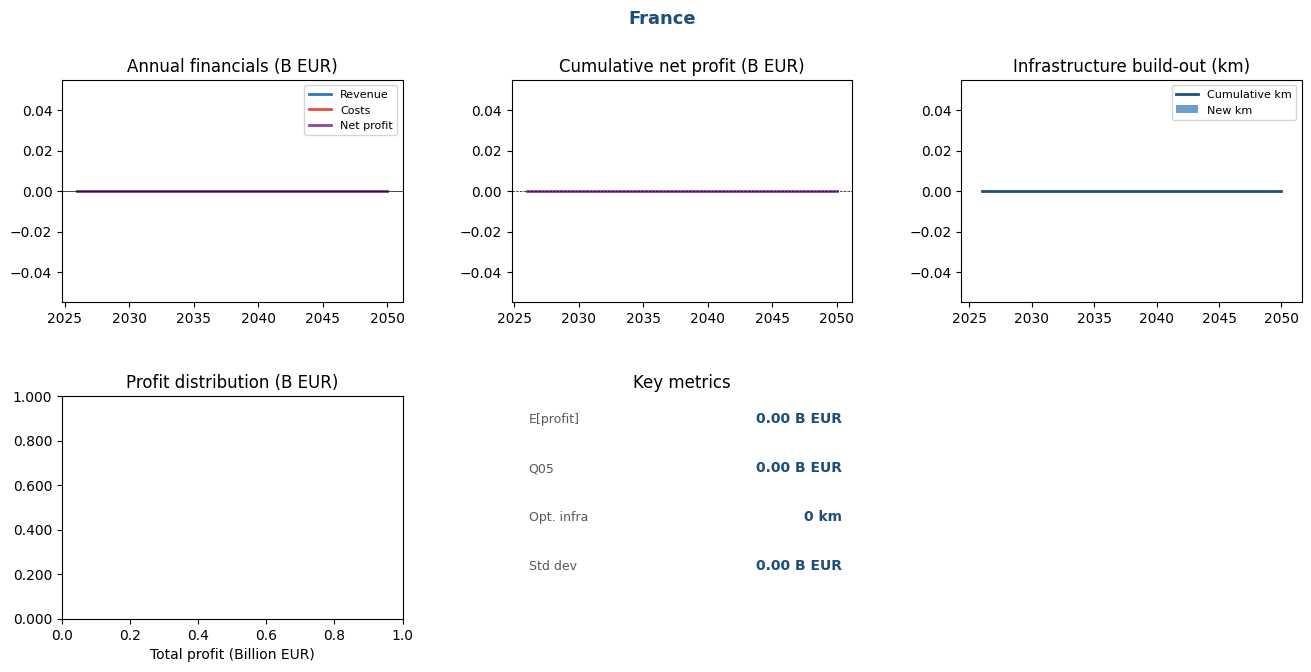

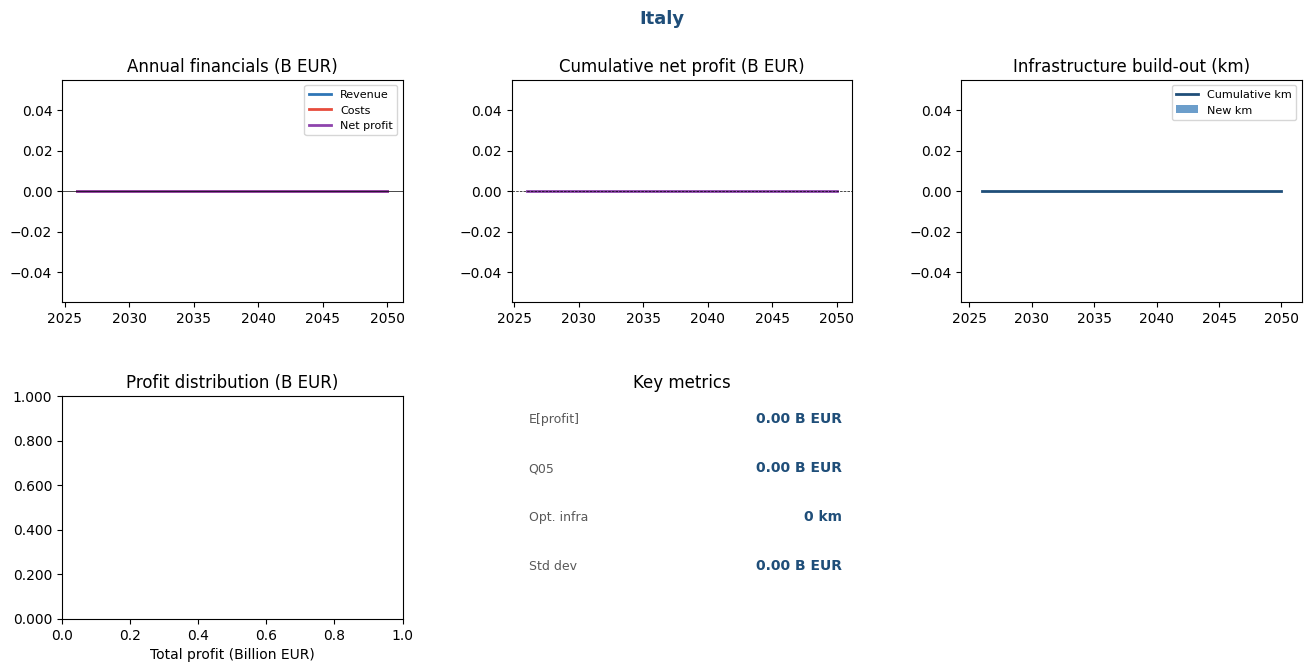

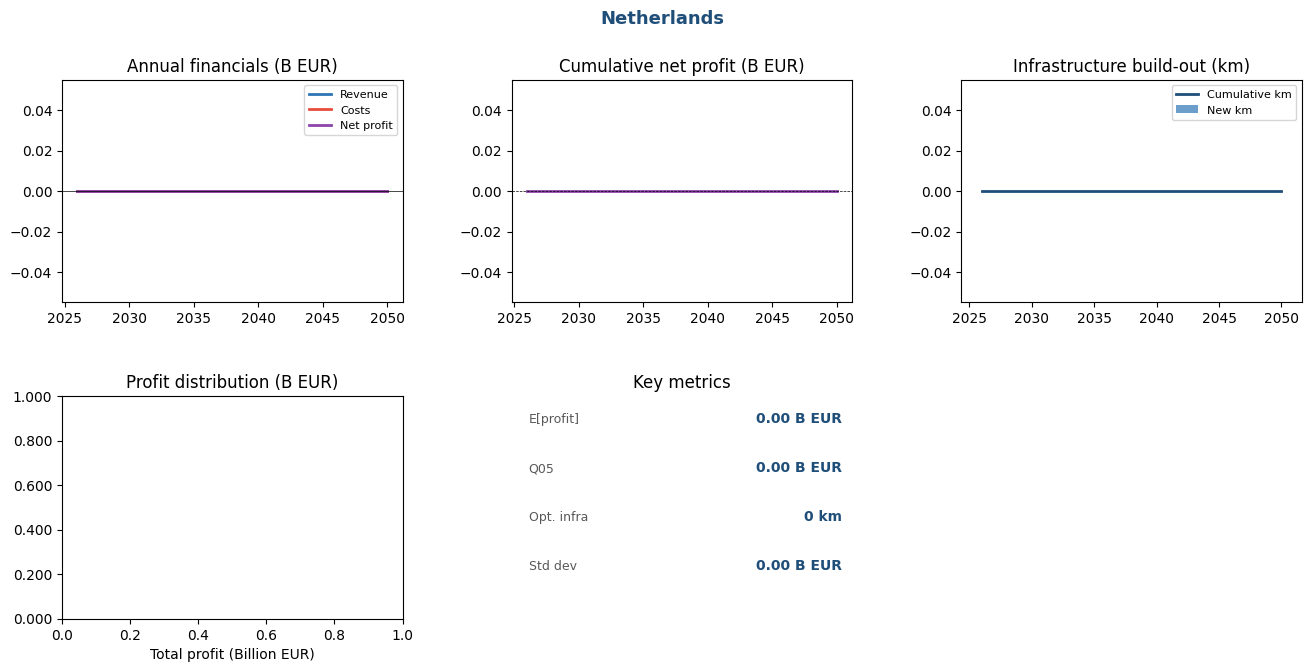

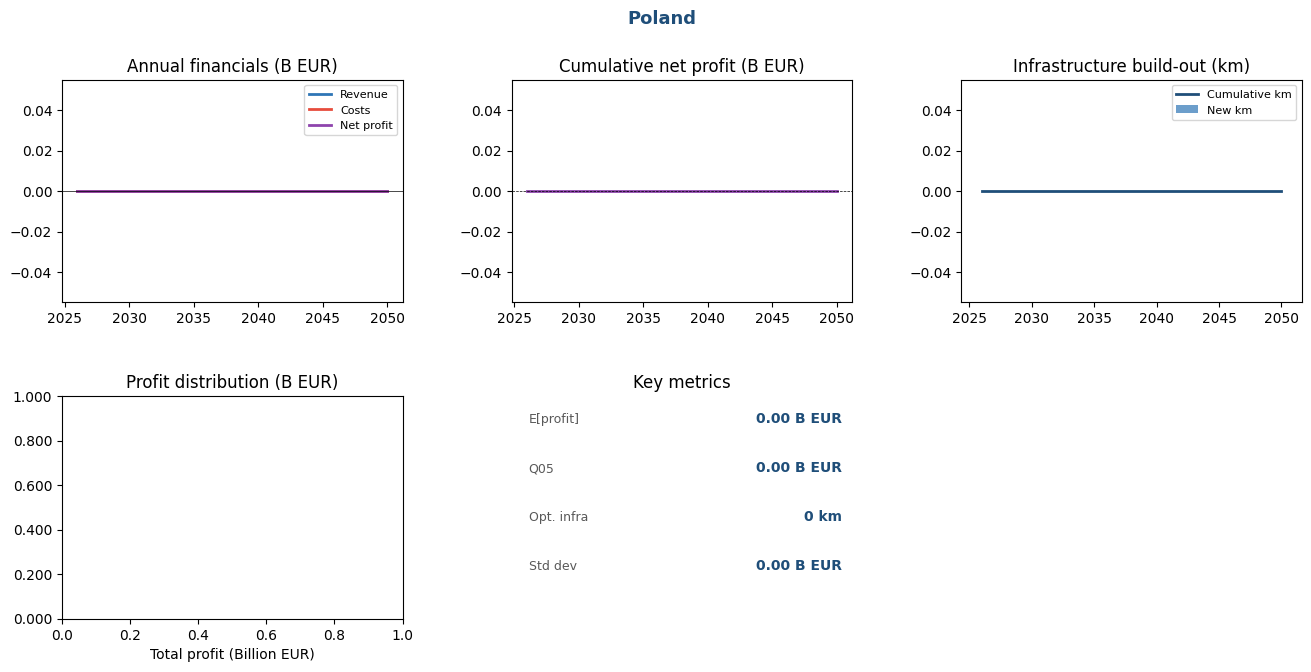


6 countries optimised


In [5]:
# ERS -- Optimise
import seekerdemo as skr

s = {
    "charging_factor": {"center":_fv(wcc),"dist":wcd.value,"p1":_fv(wcp1),"p2":_fv(wcp2)},
    "sell_price":      {"center":_fv(wsc),"dist":wsd.value,"p1":_fv(wsp1),"p2":_fv(wsp2)},
    "elec_price":      {"center":_fv(wec),"dist":wed.value,"p1":_fv(wep1),"p2":_fv(wep2)},
    "capex":           {"center":_fv(wxc),"dist":wxd.value,"p1":_fv(wxp1),"p2":_fv(wxp2)},
    "wacc":            {"center":_fv(wwc),"dist":wwd.value,"p1":_fv(wwp1),"p2":_fv(wwp2)},
    "diff_base":       {"center":_fv(wdbc),"dist":wdbd.value,"p1":_fv(wdbp1),"p2":_fv(wdbp2)},
    "diff_max":        {"center":_fv(wdmc),"dist":wdmd.value,"p1":_fv(wdmp1),"p2":_fv(wdmp2)},
    "diff_turn":       {"center":float(wdtc_int.value),"dist":wdtd.value,"p1":_fv(wdtp1),"p2":_fv(wdtp2)},
    "diff_growth":     {"center":_fv(wdgc),"dist":wdgd.value,"p1":_fv(wdgp1),"p2":_fv(wdgp2)},
}

skw_live={}
for cn,sv in skw.items():
    try: skw_live[cn]=float(sv.value)
    except: skw_live[cn]=0.9

cfg_countries=[]
for cn,cw in cww.items():
    if not cw["cb"].value: continue
    dcn=mp_name_w[cn].value.strip() if cn in mp_name_w and mp_name_w[cn].value.strip() else cn
    mkm=min(_fv(hw_w.get(cn,txt("0"))),6000)
    if mkm<=0: print(f"no highway data for {cn} -- skipped"); continue
    sig=skw_live.get(cn,0.9)
    try: dom=float(str(mp_dom_w[cn].value).replace(",","").replace(" ",""))
    except: dom=0.0
    try: cb2=float(str(mp_cb_w[cn].value).replace(",","").replace(" ",""))
    except: cb2=0.0
    cb_prob=_fv(cw["ctr"])
    total_mp=dom+cb_prob*cb2
    vol_list=[0.0]
    for km in range(100,int(mkm)+1,100):
        anteil=min(max(km/mkm,1e-7),1-1e-7)
        pen=float(np.clip(1-_norm.cdf(_norm.ppf(1-anteil)-sig**2),0,1))
        vol_list.append(pen*total_mp)
    while len(vol_list)<62: vol_list.append(vol_list[-1])
    cfg_countries.append({"name":dcn,"orig_name":cn,"max_km":mkm,"sigma":sig,
                           "vol_list":vol_list,"total_mp":total_mp})

results=[]; years=list(range(wms.value,wme.value+1)); NY=len(years)
stop_idx=wsy.value-wms.value
capex_ctr=_fv(wxc); wacc_ctr=_fv(wwc); maint_pct=_fv(wmp_)
fin_years=way.value; sys_eff_v=_fv(wse); truck_kwh_v=_fv(wtk)

def _mk(env, p):
    """Convert a parameter dict to a seekerdemo stochastic variable.
    If no bounds given: fixed value. Never defaults to +-20%."""
    d2, c, p1, p2 = p["dist"], p["center"], p["p1"], p["p2"]
    if d2 == "Uniform":
        if not p1 and not p2:
            return env.convert(c)                        # no bounds
        elif p1 and not p2:
            lo, hi = min(c, p1), max(c, p1)             # one bound -> center to bound
            return env.continuous_uniform(lo, hi)
        else:
            lo, hi = min(p1, p2), max(p1, p2)
            if lo >= hi: return env.convert(c)           # invalid bounds
            return env.continuous_uniform(lo, hi)
    elif d2 == "Normal":
        if not p1:
            return env.convert(c)                        # no std dev
        sd = p1
        return env.normal(c, sd, max(0, c - 4*sd), c + 4*sd)
    elif d2 == "Gamma (right-skewed)":
        if not p1 or not p2:
            return env.convert(c)                        # incomplete params
        sh, sc = p1, p2
        return env.gamma(sh*sc, sh*sc*3, sh*sc)
    else:
        return env.convert(c)

for country in cfg_countries:
    cn=country["name"]; vol_list=country["vol_list"]; mkm=country["max_km"]
    print(f"Optimising {cn}...")
    env=skr.Env("",True)

    ch  = _mk(env, s["charging_factor"])
    sp2 = _mk(env, s["sell_price"])
    ep  = _mk(env, s["elec_price"])
    cf  = _mk(env, s["capex"])
    wc2 = _mk(env, s["wacc"])
    db  = _mk(env, s["diff_base"])
    dm  = _mk(env, s["diff_max"])
    dt  = _mk(env, s["diff_turn"])
    dg  = _mk(env, s["diff_growth"])

    b=[env.ordinal(0,int(mkm)) for _ in range(stop_idx+1)]
    b+=[env.convert(0)]*(NY-stop_idx-1)
    total=[b[0]]
    for i in range(1,NY): total.append(env.min([total[-1]+b[i],env.convert(mkm)]))

    rev_ten=env.tensor([vol_list]*NY)
    ind2=[env.div(t,100) for t in total]
    mod2=[(t%100)/100 for t in total]
    diff=[db+(dm-db)/(1+env.exp(-dg*(y-dt))) for y in range(NY)]
    net_rpt=(sp2-ep)/sys_eff_v*truck_kwh_v*ch

    revenue=[
        ((1-mod2[y])*rev_ten[[env.convert(y),ind2[y]]]+
          mod2[y]*rev_ten[[env.convert(y),env.min([ind2[y]+1,env.convert(len(vol_list)-1)])]])
        *diff[y]*net_rpt
        for y in range(NY)
    ]

    ann_rate=wacc_ctr/(1-(1+wacc_ctr)**(-fin_years))
    yearly_costs=[]
    for y in range(NY):
        mc=total[y]*capex_ctr*cf*maint_pct
        ac=env.convert(0)
        for t in range(min(y+1,stop_idx+1)):
            if y-t<fin_years: ac=ac+b[t]*capex_ctr*cf*ann_rate
        yearly_costs.append(mc+ac)

    total_costs=env.sum(yearly_costs)
    profit=env.sum(revenue)-total_costs
    ep2=env.aggregate_mean(profit)
    q05=env.aggregate_quantile(profit,0.05,False)
    env.set_report(2,[ep2/1e6,q05/1e6],["E_profit_M","Q05_M"])
    _wv=w_weight.value if w_obj.value=="weighted" else 0.5
    if w_obj.value=="mean":
        _obj=ep2/1e6
    elif w_obj.value=="weighted":
        _obj=(_wv*ep2+(1-_wv)*q05)/1e6
    else:
        _obj=(ep2+q05)/1e6
    env.maximize(_obj,10)

    env.evaluate()

    ob=[int(b[t].get_value()) for t in range(NY)]
    oc=list(np.cumsum(ob))
    mu=ep2.get_value(); q5=q05.get_value()

    # Read annual values directly from ordinal decisions and vol_list
    rv=[]
    cv=[]
    dv=[]
    for t in range(NY):
        km_built=oc[t]
        idx=min(int(km_built//100), len(vol_list)-1)
        frac=(km_built%100)/100
        vol=vol_list[idx]*(1-frac)+(vol_list[min(idx+1,len(vol_list)-1)]*frac)
        b_val=_fv(wdbc); m_val=_fv(wdmc); turn_val=wdtc_int.value; g_val=_fv(wdgc)
        diff_val=b_val+(m_val-b_val)/(1+math.exp(-g_val*(t-turn_val)))
        net_r=(_fv(wsc)-_fv(wec))/_fv(wse)*_fv(wtk)*_fv(wcc)
        rv.append(vol*diff_val*net_r)
        ann_r=_fv(wwc)/(1-(1+_fv(wwc))**(-fin_years))
        mc=km_built*_fv(wxc)*_fv(wmp_)
        ac=sum(_fv(wxc)*ann_r*ob[s2] for s2 in range(min(t+1,stop_idx+1)) if t-s2<fin_years)
        cv.append(mc+ac)
        dv.append(diff_val)
    op=[rv[t]-cv[t] for t in range(NY)]




    sg=float(np.std(op)) if any(v!=0 for v in op) else abs(mu)*0.25

    results.append({"name":cn,"exp_profit_total":sum(op),"q05_profit":q5,"q05_profit_val":q5,
        "opt_infra_km":oc[-1],"mean_profit":sum(op),"std_profit":sg,
        "min_profit":min(op),"max_profit":max(op),"skewness":0.3,
        "annual":{"new_build":ob,"cumulative":oc,"exp_revenue":rv,
                  "exp_costs":cv,"exp_profit":op,"diffusion":dv}})
    env.end()
    print(f"  E[profit]={sum(op)/1e6:.1f}M EUR  opt_infra={oc[-1]:.0f}km")

chart_images={}
for res in results:
    cn=res["name"]; ann=res["annual"]
    fig=plt.figure(figsize=(16,7))
    fig.suptitle(cn,fontsize=13,fontweight="bold",color="#1F4E79")
    g=mgs.GridSpec(2,3,figure=fig,hspace=.42,wspace=.32)
    ax=fig.add_subplot(g[0,0])
    rv_b=[v/1e9 for v in ann["exp_revenue"]]
    cv_b=[v/1e9 for v in ann["exp_costs"]]
    op_b=[v/1e9 for v in ann["exp_profit"]]
    ax.plot(years,rv_b,color="#2E75B6",lw=2,label="Revenue")
    ax.plot(years,cv_b,color="#E74C3C",lw=2,label="Costs")
    ax.plot(years,op_b,color="#8E44AD",lw=2,label="Net profit")
    ax.axhline(0,color="k",lw=.5); ax.set_title("Annual financials (B EUR)"); ax.legend(fontsize=8)
    ax=fig.add_subplot(g[0,1])
    cp=[sum(op_b[:i+1]) for i in range(len(op_b))]
    ax.plot(years,cp,color="#8E44AD",lw=2)
    ax.fill_between(years,cp,alpha=0.1,color="#8E44AD")
    ax.axhline(0,color="k",lw=.5,ls="--"); ax.set_title("Cumulative net profit (B EUR)")
    ax=fig.add_subplot(g[0,2])
    ax.bar(years,ann["new_build"],color="#2E75B6",alpha=.7,label="New km")
    ax.plot(years,ann["cumulative"],color="#1F4E79",lw=2,label="Cumulative km")
    ax.set_title("Infrastructure build-out (km)"); ax.legend(fontsize=8)
    ax=fig.add_subplot(g[1,0])
    mu_b=res["mean_profit"]/1e9; sg_b=res["std_profit"]/1e9
    if sg_b>0:
        x_rng=np.linspace(mu_b-3.5*sg_b,mu_b+3.5*sg_b,300)
        y_dens=_norm.pdf(x_rng,mu_b,sg_b)
        ax.plot(x_rng,y_dens,color="#8E44AD",lw=2)
        ax.fill_between(x_rng,y_dens,alpha=.12,color="#8E44AD")
        ax.axvline(res["q05_profit"]/1e9,color="#E74C3C",lw=1.5,ls="--",label=f"Q05: {res['q05_profit']/1e9:.2f}B")
        ax.axvline(mu_b,color="#27AE60",lw=1.5,ls="--",label=f"Mean: {mu_b:.2f}B")
        ax.legend(fontsize=8)
    ax.set_xlabel("Total profit (Billion EUR)"); ax.set_title("Profit distribution (B EUR)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.3f}"))
    ax=fig.add_subplot(g[1,1]); ax.axis("off")
    for yi,(lbl2,val) in enumerate([
        ("E[profit]",  f"{res['exp_profit_total']/1e9:.2f} B EUR"),
        ("Q05",        f"{res['q05_profit']/1e9:.2f} B EUR"),
        ("Opt. infra", f"{res['opt_infra_km']:,.0f} km"),
        ("Std dev",    f"{res['std_profit']/1e9:.2f} B EUR"),
    ]):
        y2=.88-yi*.22
        ax.text(.05,y2,lbl2,transform=ax.transAxes,fontsize=9,color="#595959")
        ax.text(.97,y2,val,transform=ax.transAxes,fontsize=10,fontweight="bold",color="#1F4E79",ha="right")
    ax.set_title("Key metrics")
    ax=fig.add_subplot(g[1,2]); ax.axis("off")
    plt.tight_layout()
    buf2=io.BytesIO(); fig.savefig(buf2,format="png",dpi=120,bbox_inches="tight")
    buf2.seek(0); chart_images[cn]=buf2
    plt.show()

print(f"\n{len(results)} countries optimised")

---
## Section 4 -- Excel Export

In [ ]:
# ERS -- Export to Excel
from openpyxl import Workbook
from openpyxl.styles import Font,PatternFill,Alignment,Border,Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
from google.colab import files
wb2=Workbook(); ws2=wb2.active; ws2.title="Results"
th=Side(style="thin",color="BFBFBF"); B2=Border(left=th,right=th,top=th,bottom=th)
WBf=Font(name="Arial",size=10,bold=True,color="FFFFFF"); BKf=Font(name="Arial",size=10,color="000000")
HF=PatternFill("solid",fgColor="1F4E79"); SF=PatternFill("solid",fgColor="2E75B6"); GF=PatternFill("solid",fgColor="F2F2F2")
CA=Alignment(horizontal="center",vertical="center",wrap_text=True); LA=Alignment(horizontal="left",vertical="center",wrap_text=True)
def XH(r,c,v): x=ws2.cell(r,c,v); x.font=WBf; x.fill=HF; x.alignment=CA; x.border=B2
def XS(r,c,v): x=ws2.cell(r,c,v); x.font=WBf; x.fill=SF; x.alignment=LA; x.border=B2
def XL(r,c,v): x=ws2.cell(r,c,v); x.font=BKf; x.alignment=LA; x.border=B2
def XV(r,c,v=None):
    x=ws2.cell(r,c); x.fill=GF; x.border=B2; x.alignment=CA
    if v is not None: x.value=v; return x
yrs=list(range(wms.value,wme.value+1)); NY2=len(yrs); LAST=2+NY2
ws2.column_dimensions["A"].width=34; ws2.column_dimensions["B"].width=10
for i in range(NY2): ws2.column_dimensions[get_column_letter(3+i)].width=8
ws2.merge_cells(start_row=1,start_column=1,end_row=1,end_column=LAST)
t2=ws2.cell(1,1,"ERS Investment Roadmap -- Results")
t2.font=Font(name="Arial",size=14,bold=True,color="1F4E79"); t2.alignment=CA; ws2.row_dimensions[1].height=30
cur=3
for res in results:
    cn=res["name"]; ann=res["annual"]
    ws2.merge_cells(start_row=cur,start_column=1,end_row=cur,end_column=LAST)
    x=ws2.cell(cur,1,f"  {cn}"); x.font=WBf; x.fill=HF; x.alignment=LA; x.border=B2; ws2.row_dimensions[cur].height=22; cur+=1
    ws2.merge_cells(start_row=cur,start_column=1,end_row=cur,end_column=LAST); XS(cur,1,"Annual Rollout & Financial Projections"); cur+=1
    XH(cur,1,"Metric"); XH(cur,2,"Unit")
    for yi,yr in enumerate(yrs): XH(cur,3+yi,str(yr))
    ws2.row_dimensions[cur].height=20; cur+=1
    for met,unit,key in [("New infrastructure","km","new_build"),("Cumulative infra","km","cumulative"),
                          ("Expected revenue","B EUR","exp_revenue"),("Expected costs","B EUR","exp_costs"),
                          ("Expected net profit","B EUR","exp_profit"),("Market diffusion","%","diffusion")]:
        XL(cur,1,met); XL(cur,2,unit); arr=ann.get(key,[None]*NY2)
        for yi in range(NY2):
            v=arr[yi] if yi<len(arr) else None
            if v is not None and unit=="B EUR": v=round(v/1e9,4)
            elif v is not None and unit=="%": v=round(v,4)
            XV(cur,3+yi,v)
        ws2.row_dimensions[cur].height=18; cur+=1
    ws2.merge_cells(start_row=cur,start_column=1,end_row=cur,end_column=LAST); XS(cur,1,"Risk & Return Summary"); cur+=1
    XL(cur,1,"Metric"); XH(cur,3,"Value"); XH(cur,4,"Unit"); ws2.row_dimensions[cur].height=18; cur+=1
    for met,key,unit in [("Total E[profit]","exp_profit_total","B EUR"),("Q05 (5th percentile)","q05_profit","B EUR"),
                          ("Q05 value","q05_profit_val","B EUR"),("Optimal infra","opt_infra_km","km")]:
        XL(cur,1,met); v=res.get(key); v=round(v/1e9,4) if v and unit=="B EUR" else v
        XV(cur,3,v); XL(cur,4,unit)
        ws2.merge_cells(start_row=cur,start_column=5,end_row=cur,end_column=LAST); ws2.row_dimensions[cur].height=18; cur+=1
    ws2.merge_cells(start_row=cur,start_column=1,end_row=cur,end_column=LAST); XS(cur,1,"Profit Distribution Statistics"); cur+=1
    for st2,key,unit in [("Mean","mean_profit","B EUR"),("Std dev","std_profit","B EUR"),
                          ("Min (annual)","min_profit","B EUR"),("Max (annual)","max_profit","B EUR")]:
        XL(cur,1,st2); v=res.get(key); v=round(v/1e9,4) if v and unit=="B EUR" else v
        XV(cur,3,v); XL(cur,4,unit)
        ws2.merge_cells(start_row=cur,start_column=5,end_row=cur,end_column=LAST); ws2.row_dimensions[cur].height=18; cur+=1
    if cn in chart_images:
        ws2.merge_cells(start_row=cur,start_column=1,end_row=cur,end_column=LAST); XS(cur,1,"Charts"); cur+=1
        img=XLImage(chart_images[cn]); img.width=900; img.height=395
        ws2.add_image(img,f"A{cur}")
        for r2 in range(cur,cur+23): ws2.row_dimensions[r2].height=18
        cur+=24
    cur+=2
buf=io.BytesIO(); wb2.save(buf); buf.seek(0)
fname="ERS_Results.xlsx"
with open(fname,"wb") as f2: f2.write(buf.read())
files.download(fname)
print(f"{len(results)} countries exported")
